CLUSTERING ANALYSIS   
  
Understanding and Implementing K-Means and DBSCAN Algorithms
  
Objective:  
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.
Datasets :  
Data Preprocessing:  
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.  
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.  
3.	Use multiple visualizations to understand the hidden patterns in the dataset
Implementing Clustering Algorithms:  
•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.  
•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.  
•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.  

Cluster Analysis and Interpretation:  
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.
  

Visualization:  
Visualize the clustering results using scatter plots or other suitable visualization techniques.  
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.   
Evaluation and Performance Metrics:  
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
df= pd.read_excel('/content/EastWestAirlines.xlsx')
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [ ]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(3999, 12)

In [ ]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [ ]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [ ]:
df.tail()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0
3998,4021,3016,0,1,1,1,0,0,0,0,1398,0


In [ ]:
Q1=df.quantile(0.25,numeric_only=True)
Q3=df.quantile(0.75,numeric_only=True)
IQR=Q3-Q1
mask=~((df.select_dtypes(include='number')<(Q1-1.5*IQR))|(df.select_dtypes(include='number')>(Q3+1.5*IQR))).any(axis=1)
df=df[mask]
df


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
5,6,16420,0,1,1,1,0,0,0,0,6942,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3992,4015,11181,0,1,1,1,929,12,0,0,1407,0
3993,4016,3974,0,1,1,1,365,3,0,0,1397,0
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1


In [ ]:
X=df.select_dtypes(include='number')
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.864146,-0.283697,0.0,-0.648136,0.0,0.0,-0.765732,-1.002621,0.0,0.0,1.540129,-0.550707
1,-1.863285,-0.561675,0.0,-0.648136,0.0,0.0,-0.761816,-0.867046,0.0,0.0,1.524611,-0.550707
2,-1.862425,0.128974,0.0,-0.648136,0.0,0.0,-0.388530,-0.595896,0.0,0.0,1.556616,-0.550707
3,-1.861564,-0.701241,0.0,-0.648136,0.0,0.0,-0.734593,-1.002621,0.0,0.0,1.516853,-0.550707
4,-1.859843,-0.649888,0.0,-0.648136,0.0,0.0,-0.782352,-1.138196,0.0,0.0,1.512004,-0.550707
...,...,...,...,...,...,...,...,...,...,...,...,...
2221,1.589849,-0.813538,0.0,-0.648136,0.0,0.0,-0.693616,0.488703,0.0,0.0,-1.172028,-0.550707
2222,1.590710,-1.038663,0.0,-0.648136,0.0,0.0,-0.747488,-0.731471,0.0,0.0,-1.176878,-0.550707
2223,1.592430,0.848392,0.0,-0.648136,0.0,0.0,-0.688649,-0.460322,0.0,0.0,-1.177847,1.815846
2224,1.593291,1.136147,0.0,1.335028,0.0,0.0,1.648305,-0.053597,0.0,0.0,-1.174453,1.815846


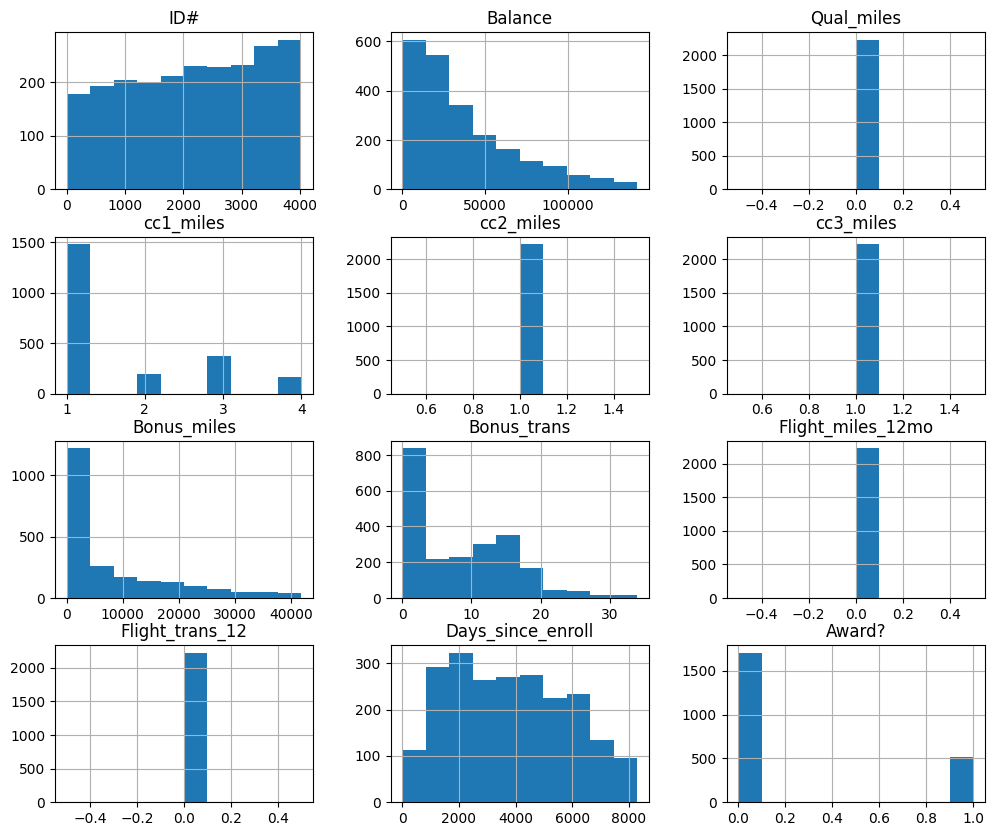

In [ ]:
df.hist(figsize=(12,10))
plt.show()

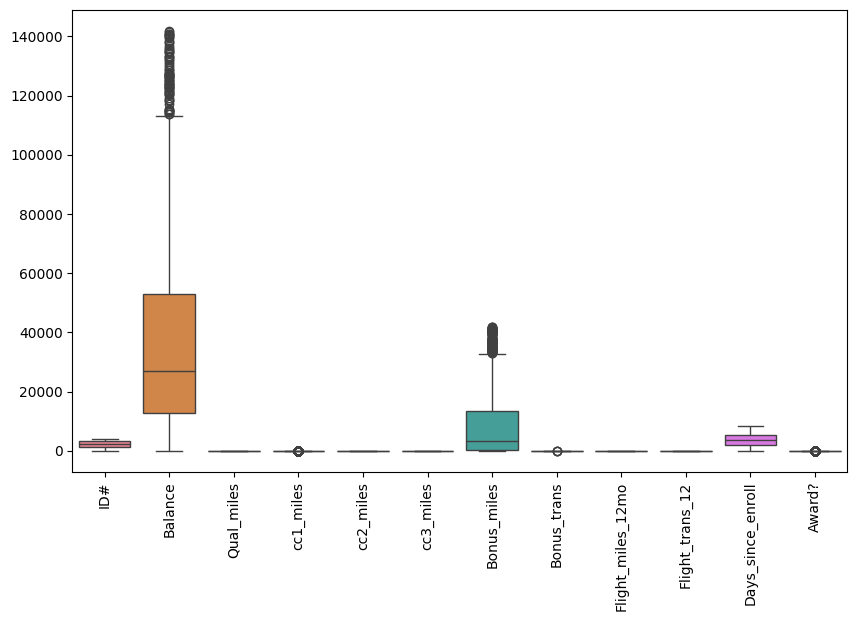

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()


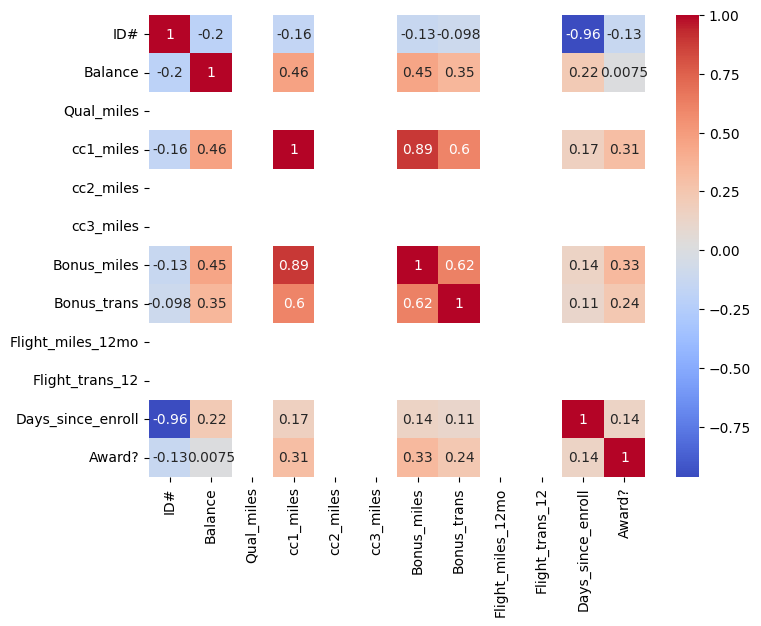

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

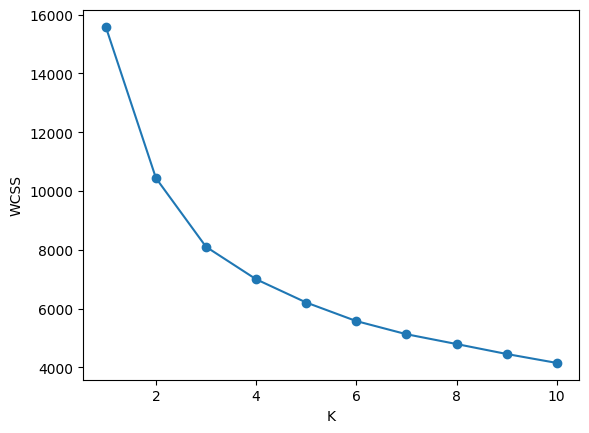

Silhouette Score: 0.29178993558827443


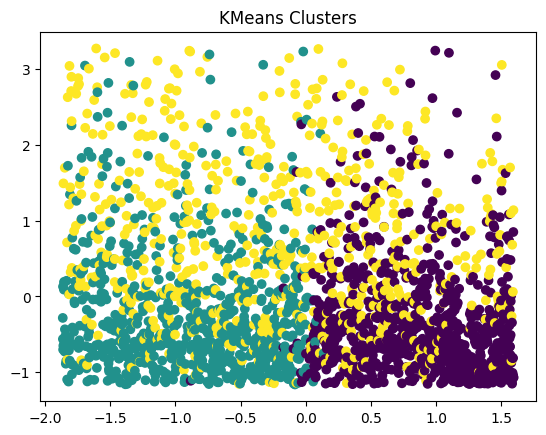

In [ ]:
wcss=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
k_labels=kmeans.fit_predict(X_scaled)
print('Silhouette Score:',silhouette_score(X_scaled,k_labels))
plt.scatter(X_scaled.iloc[:,0],X_scaled.iloc[:,1],c=k_labels,cmap='viridis')
plt.title('KMeans Clusters')
plt.show()

Silhouette: 0.27106034872039514


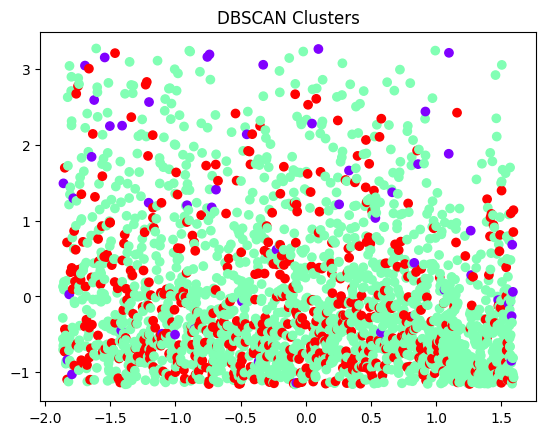

In [ ]:
#DBSCAN
db=DBSCAN(eps=1.2,min_samples=5)
db_labels=db.fit_predict(X_scaled)
valid=db_labels!=-1
if len(set(db_labels[valid]))>1:
    print('Silhouette:',silhouette_score(X_scaled[valid],db_labels[valid]))
else:
    print('Silhouette cannot be computed.')
plt.scatter(X_scaled.iloc[:,0],X_scaled.iloc[:,1],c=db_labels,cmap='rainbow')
plt.title('DBSCAN Clusters')
plt.show()

Interpretation  
K-Means partitions customers into predefined clusters.  
Elbow curve helps choose the optimal K.  
DBSCAN detects dense regions and labels isolated observations as noise.  
Compare silhouette scores to determine which algorithm performs better.


Conclusion  
K-Means generally performs well on well-separated data, while DBSCAN is useful for discovering arbitrarily shaped clusters and identifying outliers. The better model is the one with the higher silhouette score and more meaningful business interpretation.  

